<a href="https://colab.research.google.com/github/luisenrique2610/Terminal-de-Economia/blob/main/Proyecto_Economia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### DETECCION DE FRAUDES EN TARJETAS DE CREDITO

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
#df_fraud = pd.read_csv('/content/Fraudulent_E-Commerce_Transaction_Data.csv')
#df_fraud.head(5)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_fraud = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Fraudulent_E-Commerce_Transaction_Data.csv')
df_fraud.head(5)

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


In [ ]:
df_fraud.columns = ['ID de la transaccion', 'ID del cliente', 'Mon†o de la transaccion', 'Fecha de la transaccion', 'Metodo de pago', 'Categoria del producto', 'Cantidad', 'Edad del cliente','Localizacion del cliente', 'Dispositivo usado', 'Direccion IP', 'Direccion de envio', 'Direccion de facturacion', '¿Es fraudulenta?','Dias desde creacion de la cuenta', 'Hora de la transaccion'] #Cambiar nombre de columnas
df_fraud.head()

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Fecha de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora de la transaccion
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


In [ ]:
df_fraud['Fecha'] = pd.to_datetime(df_fraud['Fecha de la transaccion']).dt.date
df_fraud['Hora'] = pd.to_datetime(df_fraud['Fecha de la transaccion']).dt.time
df_fraud = df_fraud.drop('Fecha de la transaccion', axis=1)
df_fraud = df_fraud.drop('Hora de la transaccion', axis=1)

In [ ]:
df_fraud.head()

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Fecha,Hora
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,2024-02-20,05:58:41
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,2024-02-25,08:09:45
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,2024-03-18,03:42:55
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,2024-03-16,20:41:31
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,2024-01-15,05:08:17


In [ ]:
df_fraud['Fecha'] = pd.to_datetime(df_fraud['Fecha'])
df_fraud['Año'] = df_fraud['Fecha'].dt.year
df_fraud['Mes'] = df_fraud['Fecha'].dt.month
df_fraud['Dia'] = df_fraud['Fecha'].dt.day
df_fraud.head()

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Fecha,Hora,Año,Mes,Dia
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,2024-02-20,05:58:41,2024,2,20
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,2024-02-25,08:09:45,2024,2,25
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,2024-03-18,03:42:55,2024,3,18
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,2024-03-16,20:41:31,2024,3,16
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,2024-01-15,05:08:17,2024,1,15


In [ ]:
df_fraud = df_fraud.drop(['Fecha'], axis=1)
df_fraud.head()

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora,Año,Mes,Dia
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,05:58:41,2024,2,20
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,08:09:45,2024,2,25
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,03:42:55,2024,3,18
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20:41:31,2024,3,16
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,05:08:17,2024,1,15


In [ ]:
df_fraud.describe().apply(lambda x: x.round(3))

,Mon†o de la transaccion,Cantidad,Edad del cliente,¿Es fraudulenta?,Dias desde creacion de la cuenta,Año,Mes,Dia
count,1472952.000,1472952.000,1472952.000,1472952.000,1472952.000,1472952.0,1472952.000,1472952.000
mean,226.768,3.000,34.512,0.050,179.646,2024.0,2.050,15.332
std,270.395,1.415,10.003,0.218,106.864,0.0,0.873,8.938
min,10.000,1.000,-16.000,0.000,1.000,2024.0,1.000,1.000
25%,68.610,2.000,28.000,0.000,86.000,2024.0,1.000,7.000
50%,151.760,3.000,35.000,0.000,179.000,2024.0,2.000,15.000
75%,296.050,4.000,41.000,0.000,272.000,2024.0,3.000,23.000
max,12701.750,5.000,86.000,1.000,365.000,2024.0,4.000,31.000


In [ ]:
df_fraud['Año']=df_fraud['Año'].astype(object)
df_fraud['Mes']=df_fraud['Mes'].astype(object)
df_fraud['Dia']=df_fraud['Dia'].astype(object)
df_fraud.head(5)

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora,Año,Mes,Dia
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,05:58:41,2024,2,20
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,08:09:45,2024,2,25
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,03:42:55,2024,3,18
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20:41:31,2024,3,16
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,05:08:17,2024,1,15


In [ ]:
df_fraud['¿Es fraudulenta?']=df_fraud['¿Es fraudulenta?'].astype(bool)
df_fraud.head(5)

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora,Año,Mes,Dia
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,False,30,05:58:41,2024,2,20
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",False,72,08:09:45,2024,2,25
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",False,63,03:42:55,2024,3,18
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",False,124,20:41:31,2024,3,16
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",False,158,05:08:17,2024,1,15


In [ ]:
df_fraud.describe().apply(lambda x: x.round(3))

,Mon†o de la transaccion,Cantidad,Edad del cliente,Dias desde creacion de la cuenta
count,1472952.000,1472952.000,1472952.000,1472952.000
mean,226.768,3.000,34.512,179.646
std,270.395,1.415,10.003,106.864
min,10.000,1.000,-16.000,1.000
25%,68.610,2.000,28.000,86.000
50%,151.760,3.000,35.000,179.000
75%,296.050,4.000,41.000,272.000
max,12701.750,5.000,86.000,365.000


In [ ]:
df_fraud['Edad del cliente'].value_counts()

,count
Edad del cliente,
35,58910
36,58801
34,58402
33,58061
32,56964
...,...
-13,2
-10,2
-11,1


In [ ]:
mask = df_fraud['Edad del cliente'] >= 18
df_fraud = df_fraud[mask]
df_fraud.head()

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora,Año,Mes,Dia
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",False,72,08:09:45,2024,2,25
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",False,63,03:42:55,2024,3,18
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",False,124,20:41:31,2024,3,16
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",False,158,05:08:17,2024,1,15
5,4e707452-7c8a-4cbd-b0c1-2aeaa35c5e88,29616b04-2d5c-4729-9c9d-8d71a6ad9dc1,166.41,bank transfer,toys & games,2,34,Herreramouth,tablet,202.237.29.55,"5699 Brittany Villages Suite 903\nLake Tim, MD...","120 Kristi Dale\nPort Meganshire, GU 03060",False,38,10:55:14,2024,1,30


In [ ]:
df_fraud.info()
df_fraud.describe().apply(lambda x: x.round(3))

<class 'pandas.core.frame.DataFrame'>
Index: 1407480 entries, 1 to 1472951
Data columns (total 18 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   ID de la transaccion              1407480 non-null  object 
 1   ID del cliente                    1407480 non-null  object 
 2   Mon†o de la transaccion           1407480 non-null  float64
 3   Metodo de pago                    1407480 non-null  object 
 4   Categoria del producto            1407480 non-null  object 
 5   Cantidad                          1407480 non-null  int64  
 6   Edad del cliente                  1407480 non-null  int64  
 7   Localizacion del cliente          1407480 non-null  object 
 8   Dispositivo usado                 1407480 non-null  object 
 9   Direccion IP                      1407480 non-null  object 
 10  Direccion de envio                1407480 non-null  object 
 11  Direccion de facturacion          1407480 

,Mon†o de la transaccion,Cantidad,Edad del cliente,Dias desde creacion de la cuenta
count,1407480.000,1407480.000,1407480.000,1407480.000
mean,226.754,3.000,35.495,179.672
std,270.434,1.415,9.075,106.872
min,10.000,1.000,18.000,1.000
25%,68.610,2.000,29.000,86.000
50%,151.770,3.000,35.000,179.000
75%,296.000,4.000,42.000,272.000
max,12701.750,5.000,86.000,365.000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_fraud.to_csv('/content/drive/MyDrive/Colab Notebooks/df_fraud.csv')

In [ ]:
df_fraud = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/df_fraud.csv')
df_fraud.head(5)

,Unnamed: 0,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora,Año,Mes,Dia
0,1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",False,72,08:09:45,2024,2,25
1,2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",False,63,03:42:55,2024,3,18
2,3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",False,124,20:41:31,2024,3,16
3,4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",False,158,05:08:17,2024,1,15
4,5,4e707452-7c8a-4cbd-b0c1-2aeaa35c5e88,29616b04-2d5c-4729-9c9d-8d71a6ad9dc1,166.41,bank transfer,toys & games,2,34,Herreramouth,tablet,202.237.29.55,"5699 Brittany Villages Suite 903\nLake Tim, MD...","120 Kristi Dale\nPort Meganshire, GU 03060",False,38,10:55:14,2024,1,30


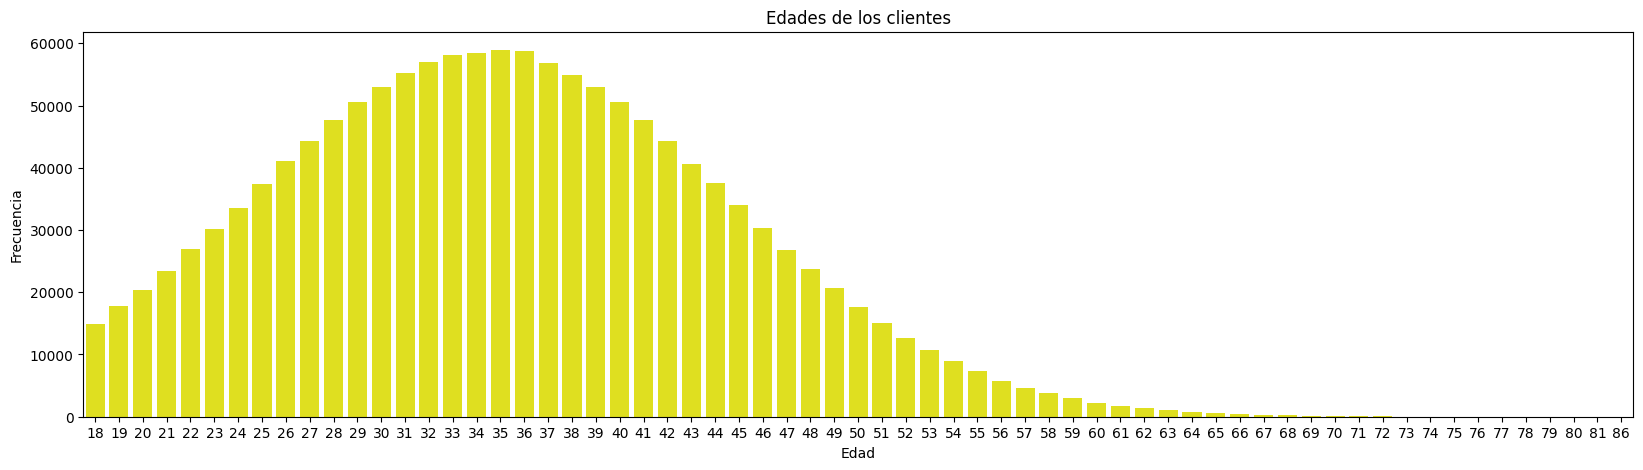

In [ ]:
plt.figure(figsize=(20,5))
sns.countplot(x='Edad del cliente', data=df_fraud, color = 'Yellow')
plt.title('Edades de los clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
df_fraud.dtypes

,0
Unnamed: 0,int64
ID de la transaccion,object
ID del cliente,object
Mon†o de la transaccion,float64
Metodo de pago,object
Categoria del producto,object
Cantidad,int64
Edad del cliente,int64
Localizacion del cliente,object
Dispositivo usado,object


In [ ]:
#Veamos la diferencia entre las transacciones fraudulentas y las normales
print("Distribucion de Normal(0) y Fraudes(1): ")
print(df_fraud['¿Es fraudulenta?'].value_counts())

Distribucion de Normal(0) y Fraudes(1): 
¿Es fraudulenta?
False    1336993
True       70487
Name: count, dtype: int64


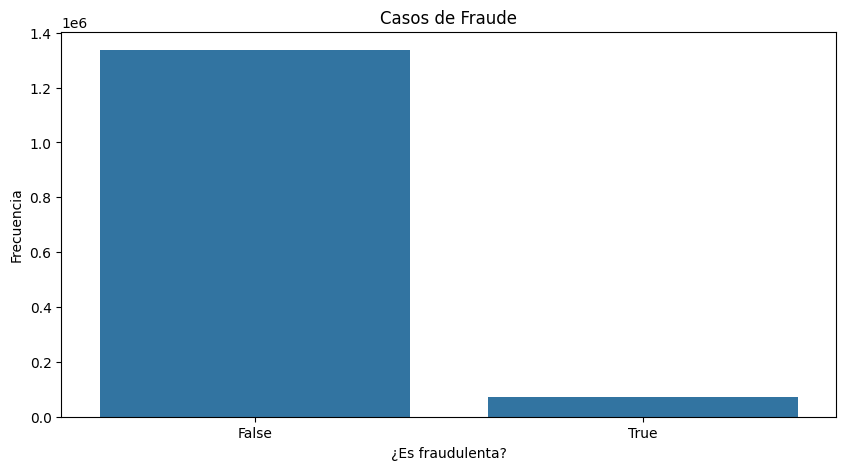

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='¿Es fraudulenta?', data=df_fraud)
plt.title('Casos de Fraude')
plt.xlabel('¿Es fraudulenta?')
plt.ylabel('Frecuencia')
plt.show()

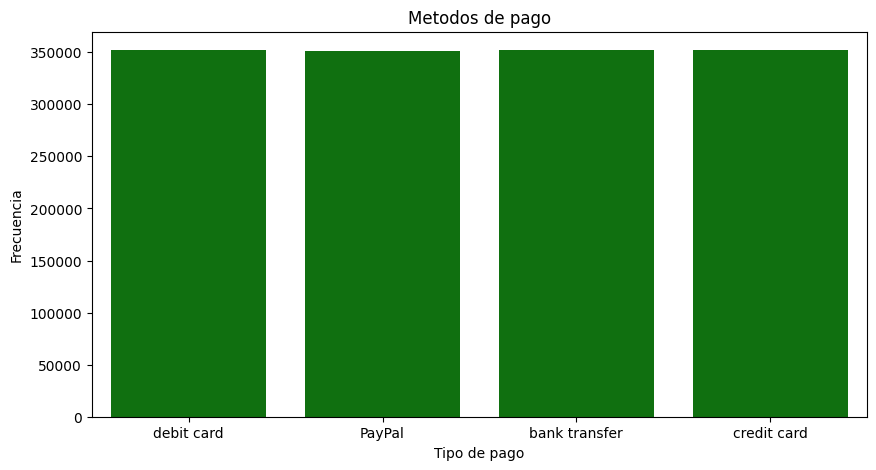

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Metodo de pago', data=df_fraud, color = 'green')
plt.title('Metodos de pago')
plt.xlabel('Tipo de pago')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
df_fraud['Metodo de pago'].value_counts()

,count
Metodo de pago,
credit card,352105
debit card,351956
bank transfer,351889
PayPal,351530


In [ ]:
df_fraud['Dispositivo usado'].value_counts()

,count
Dispositivo usado,
mobile,470056
tablet,468967
desktop,468457


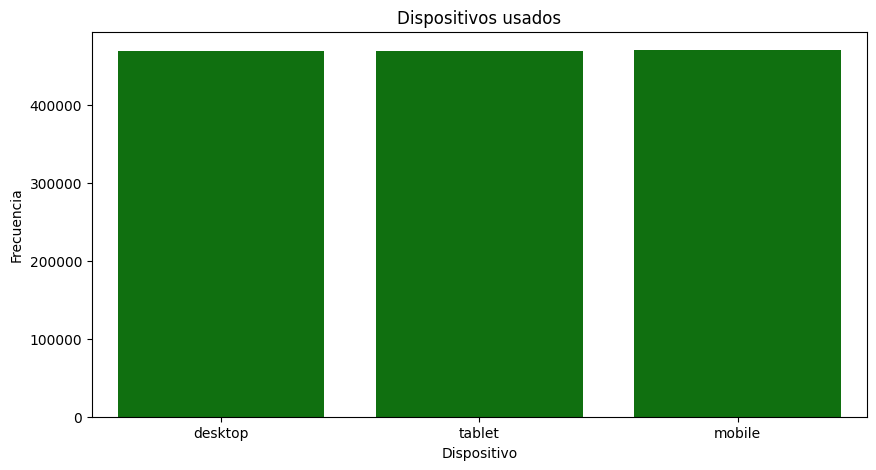

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Dispositivo usado', data=df_fraud,color = 'green')
plt.title('Dispositivos usados')
plt.xlabel('Dispositivo')
plt.ylabel('Frecuencia')
plt.show()


In [ ]:
df_fraud['Categoria del producto'].value_counts()

,count
Categoria del producto,
health & beauty,282311
electronics,282135
clothing,281289
toys & games,281000
home & garden,280745


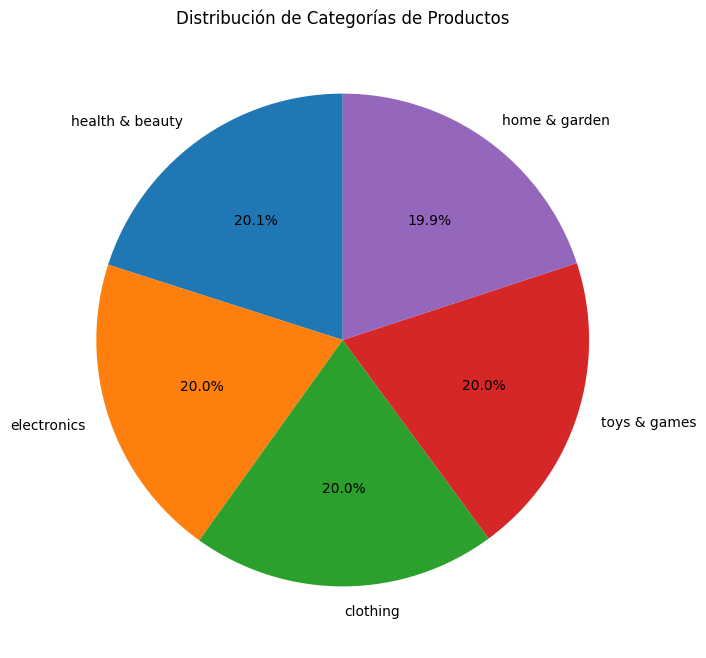

In [ ]:
import matplotlib.pyplot as plt

# Cuenta la frecuencia de cada categoría de producto
category_counts = df_fraud['Categoria del producto'].value_counts()

# Crea la gráfica de pastel
plt.figure(figsize=(8, 8))  # Ajusta el tamaño de la figura si es necesario
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Categorías de Productos')
plt.show()

In [ ]:
df_fraud['Mon†o de la transaccion'].describe().round(3)

,Mon†o de la transaccion
count,1407480.000
mean,226.754
std,270.434
min,10.000
25%,68.610
50%,151.770
75%,296.000
max,12701.750


<ipython-input-42-dcb38b0bf20c>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fraudes['Mon†o de la transaccion'], color='red', label='Fraudes')
<ipython-input-42-dcb38b0bf20c>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(no_fraudes['Mon†o de la transaccion'], color='green', label='No Frau

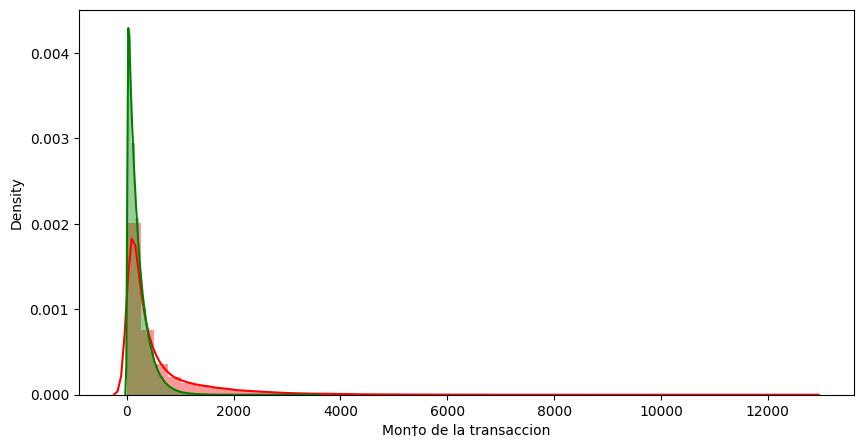

In [ ]:
fraudes = df_fraud[df_fraud['¿Es fraudulenta?'] == True]
no_fraudes = df_fraud[df_fraud['¿Es fraudulenta?'] == False]

plt.figure(figsize=(10,5))
sns.distplot(fraudes['Mon†o de la transaccion'], color='red', label='Fraudes')
sns.distplot(no_fraudes['Mon†o de la transaccion'], color='green', label='No Fraudes')
plt.show()

In [ ]:
total_por_categoria = df_fraud['Categoria del producto'].value_counts()
fraudes_por_categoria = df_fraud[df_fraud['¿Es fraudulenta?'] == True]['Categoria del producto'].value_counts()

porcentaje_fraudes_por_categoria = ((fraudes_por_categoria / total_por_categoria) * 100).sort_values(ascending=False)
print(porcentaje_fraudes_por_categoria)

Categoria del producto
toys & games       5.040925
clothing           5.034680
home & garden      5.013446
health & beauty    5.000868
electronics        4.950467
Name: count, dtype: float64


<Axes: xlabel='Categoria del producto', ylabel='count'>

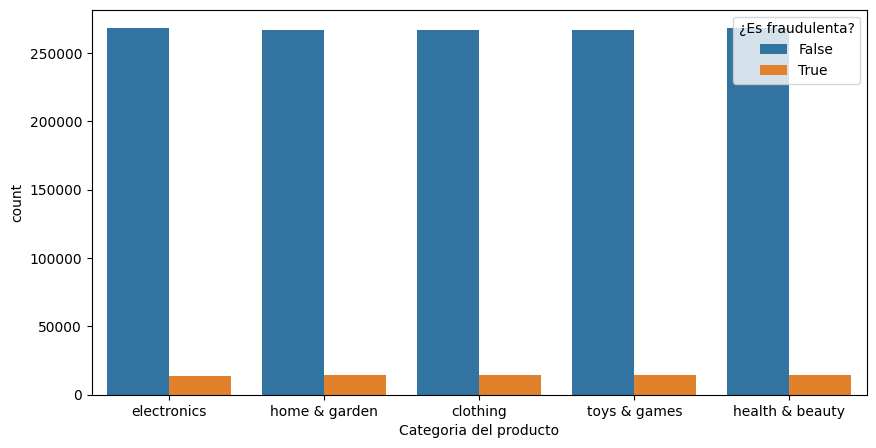

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Categoria del producto', data=df_fraud, hue='¿Es fraudulenta?')

In [ ]:
df_fraud['Año']=df_fraud['Año'].astype(object)
df_fraud['Mes']=df_fraud['Mes'].astype(object)
df_fraud['Dia']=df_fraud['Dia'].astype(object)
df_fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407480 entries, 0 to 1407479
Data columns (total 19 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   Unnamed: 0                        1407480 non-null  int64  
 1   ID de la transaccion              1407480 non-null  object 
 2   ID del cliente                    1407480 non-null  object 
 3   Mon†o de la transaccion           1407480 non-null  float64
 4   Metodo de pago                    1407480 non-null  object 
 5   Categoria del producto            1407480 non-null  object 
 6   Cantidad                          1407480 non-null  int64  
 7   Edad del cliente                  1407480 non-null  int64  
 8   Localizacion del cliente          1407480 non-null  object 
 9   Dispositivo usado                 1407480 non-null  object 
 10  Direccion IP                      1407480 non-null  object 
 11  Direccion de envio                140

In [ ]:
# Para elementos numericos
numeric_features = df_fraud.select_dtypes(include=np.number)

# Calculate the correlation matrix
corr_matrix = numeric_features.corr()

# Display the correlation matrix
corr_matrix

,Unnamed: 0,Mon†o de la transaccion,Cantidad,Edad del cliente,Dias desde creacion de la cuenta
Unnamed: 0,1.000000,-0.000019,0.000316,-0.000150,-0.000487
Mon†o de la transaccion,-0.000019,1.000000,-0.000686,0.000505,-0.035707
Cantidad,0.000316,-0.000686,1.000000,0.000420,0.001244
Edad del cliente,-0.000150,0.000505,0.000420,1.000000,-0.000013
Dias desde creacion de la cuenta,-0.000487,-0.035707,0.001244,-0.000013,1.000000


<Axes: >

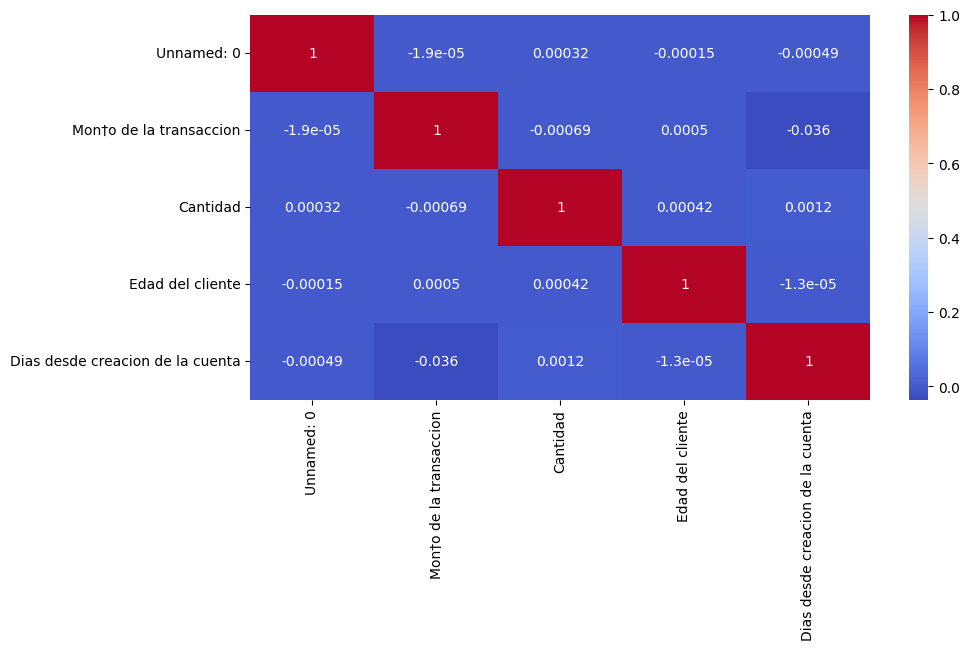

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')